In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ackley(x):
    x = np.asarray(x)
    return - 20 * np.exp(- 0.2 * np.sqrt(np.sum(x ** 2) / len(x))) - np.exp(np.sum(np.cos(2 * np.pi * x)) / len(x)) + 20 + np.e

def rastrigin(x):
    x = np.asarray(x)
    return 10 * len(x) + np.sum(x ** 2 - 10 * np.cos(2 * np.pi * x))

def holder(x):
    x1, x2 = float(x[0]), float(x[1])
    return - abs(np.sin(x1) * np.cos(x2) * np.exp(abs(1 - np.sqrt(x1 ** 2 + x2 ** 2) / np.pi)))

In [3]:
class SimulatedAnnealing:
    def __init__(self, func, dim, bounds, T0=1, alpha=0.99, steps=2000):
        self.func = func
        self.dim = dim
        self.bounds = bounds
        self.T0 = T0
        self.alpha = alpha
        self.steps = steps

    def random_point(self):
        low, high = self.bounds
        return np.random.uniform(low, high, self.dim)

    def neighbor(self, x, T):
        low, high = self.bounds
        x_new = x + np.random.normal(0, T, self.dim)
        return np.clip(x_new, low, high)

    def run(self):
        x = self.random_point()
        fx = self.func(x)
        best = fx
        T = self.T0
        history = []

        for _ in range(self.steps):
            x_new = self.neighbor(x, T)
            f_new = self.func(x_new)

            if f_new < fx or np.random.rand() < np.exp((fx - f_new)/T):
                x, fx = x_new, f_new

            best = min(best, fx)
            history.append(best)
            T *= self.alpha

        return np.array(history)

In [4]:
def plot_history(H, title):
    m, s = H.mean(0), H.std(0)
    plt.figure()
    plt.plot(m)
    plt.fill_between(range(len(m)), m-s, m+s, alpha=0.2)
    if np.all(m > 0):
        plt.yscale("log")
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Value")
    plt.show()

In [5]:
def experiment(*args, **kwargs):
    H = np.array([
        SimulatedAnnealing(*args, **kwargs).run()
        for _ in range(30)
    ])
    return H

In [6]:
def stats(H, name):
    f = H[:, -1]
    print(name)
    print("Mean:", f.mean(), 
          "Min:", f.min(), 
          "Max:", f.max(), 
          "Std:", f.std(), "\n")

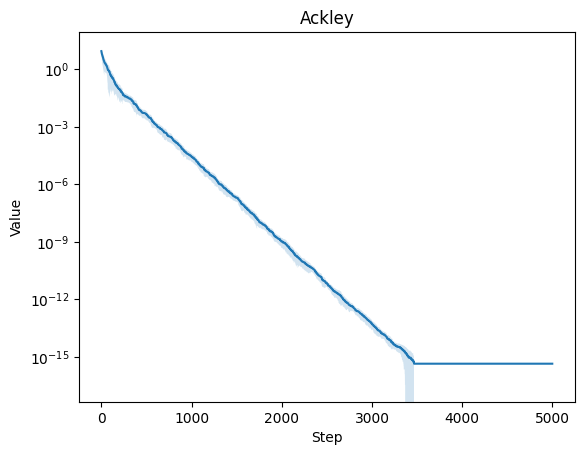

Ackley
Mean: 4.440892098500626e-16 Min: 4.440892098500626e-16 Max: 4.440892098500626e-16 Std: 0.0 



In [7]:
H_ack = experiment(
    ackley,
    dim=2,
    bounds=(-5, 5),
    T0=1.0,
    alpha=0.99,
    steps=5000
)

plot_history(H_ack, "Ackley")
stats(H_ack, "Ackley")

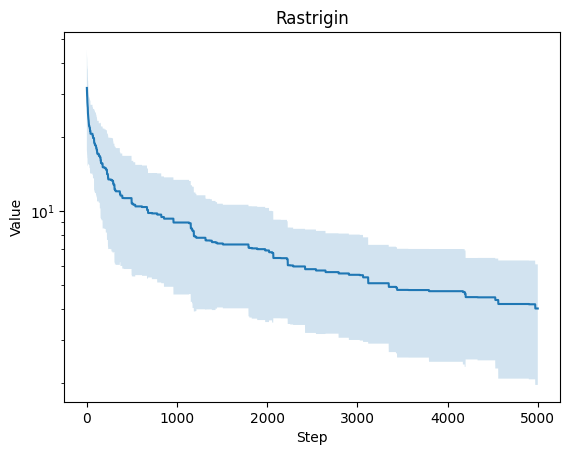

Rastrigin
Mean: 4.030143430884741 Min: 1.2539505680455854 Max: 8.46959785458027 Std: 2.0568638284342335 



In [19]:
H_ras = experiment(
    rastrigin,
    dim=2,
    bounds=(-5, 5),
    T0=20.0,
    alpha=0.9999999999,
    steps=5000
)

plot_history(H_ras, "Rastrigin")
stats(H_ras, "Rastrigin")

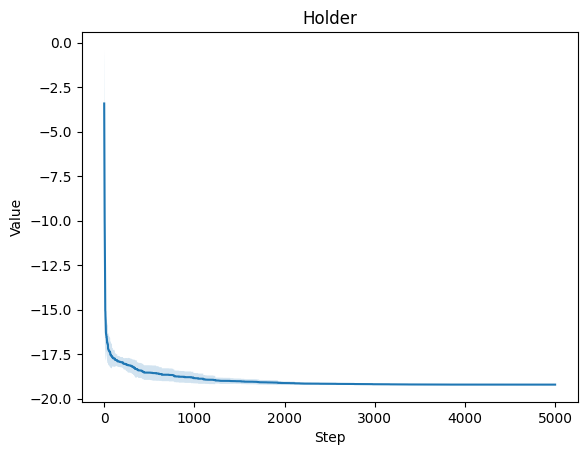

Holder
Mean: -19.204934331649568 Min: -19.207897860522483 Max: -19.198575602681178 Std: 0.002357415134891998 



In [9]:
H_hol = experiment(
    holder,
    dim=2,
    bounds=(-10, 10),
    T0=5.0,
    alpha=0.9995,
    steps=5000
)

plot_history(H_hol, "Holder")
stats(H_hol, "Holder")